**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore - thiol concentration](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
  - [Prediction of photophysical statistics](#toc1_3_)    
  - [Figure](#toc1_4_)    
    - [Preparation](#toc1_4_1_)    
    - [Figure](#toc1_4_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore - thiol concentration](#toc0_)

In [1]:
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from lmfit import Model, Parameters
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.prediction as pr
import fluopy.routines as rt
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

reading_from = r"D:\python_output\Chapter_I\1_6_PET_rate"

## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [2]:
def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(dist.two_expon_mixture_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

In [3]:
identifiers = ["100", "50", "10", "1"]
fingerprints_all = []
total_photons = []
ON_periods_frames = []
OFF_periods_frames = []
parameters_all_fit_cdf = []
folder_path = reading_from
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    total_photons.append([])
    ON_periods_frames.append([])
    OFF_periods_frames.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all[i] += data.sum(axis=1)
            total_photons[i] += data.sum(axis=0).values.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_frames[i] += blinks.off_periods.tolist()
                ON_periods_frames[i] += blinks.on_periods.tolist()
    fingerprint = fingerprints_all[i].cumsum() / fingerprints_all[i].sum()
    fingerprints_all[i] = fingerprint
    parameters_all_fit_cdf.append(fit_two_expon_mixture(fingerprint))

## <a id='toc1_3_'></a>[Prediction of photophysical statistics](#toc0_)

In [4]:
PARAMS_ADJ = {k: v for k, v in rt.PARAMS_DSTORM.items() if k != "dstorm_parameters"}
fluorophores = fl.construct_fluorophores(name="cy5_dna", count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)


def prepare_transition_set(conc):
    transitions = fluorophore_system.load_transitions(
        bleaching=False,
        **PARAMS_ADJ,
        summarize=False,
        dstorm_parameters={
            "reducing_agent": "mea",
            "concentration": conc,
            "ph": 7.5,
        },
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    return transition_set

In [5]:
transition_set100 = prepare_transition_set(conc=100)
pred100 = pr.Prediction(transition_set100)
transition_set1 = prepare_transition_set(conc=1)
pred1 = pr.Prediction(transition_set1)

## <a id='toc1_4_'></a>[Figure](#toc0_)

### <a id='toc1_4_1_'></a>[Preparation](#toc0_)

In [6]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


def prepare_data(total_photons, ON_periods_frames, OFF_periods_frames, in_s):
    total_photons = [np.array(d) for d in total_photons]
    ON_periods = [np.array(d) * in_s for d in ON_periods_frames]
    OFF_periods = [np.array(d) * in_s for d in OFF_periods_frames]
    log_bins_photons = get_log_bins(total_photons)
    log_bins_OFF = get_log_bins(OFF_periods)
    weights_photons = [np.ones_like(d) / d.size for d in total_photons]
    weights_ON = [np.ones_like(d) / d.size for d in ON_periods]
    weights_OFF = [np.ones_like(d) / d.size for d in OFF_periods]
    return (
        total_photons,
        ON_periods,
        OFF_periods,
        log_bins_photons,
        log_bins_OFF,
        weights_photons,
        weights_ON,
        weights_OFF,
    )


in_s = emis.event_time_series.index[1] - emis.event_time_series.index[0]
(
    total_photons,
    ON_periods,
    OFF_periods,
    log_bins_photons,
    log_bins_OFF,
    weights_photons,
    weights_ON,
    weights_OFF,
) = prepare_data(total_photons, ON_periods_frames, OFF_periods_frames, in_s)

### <a id='toc1_4_2_'></a>[Figure](#toc0_)

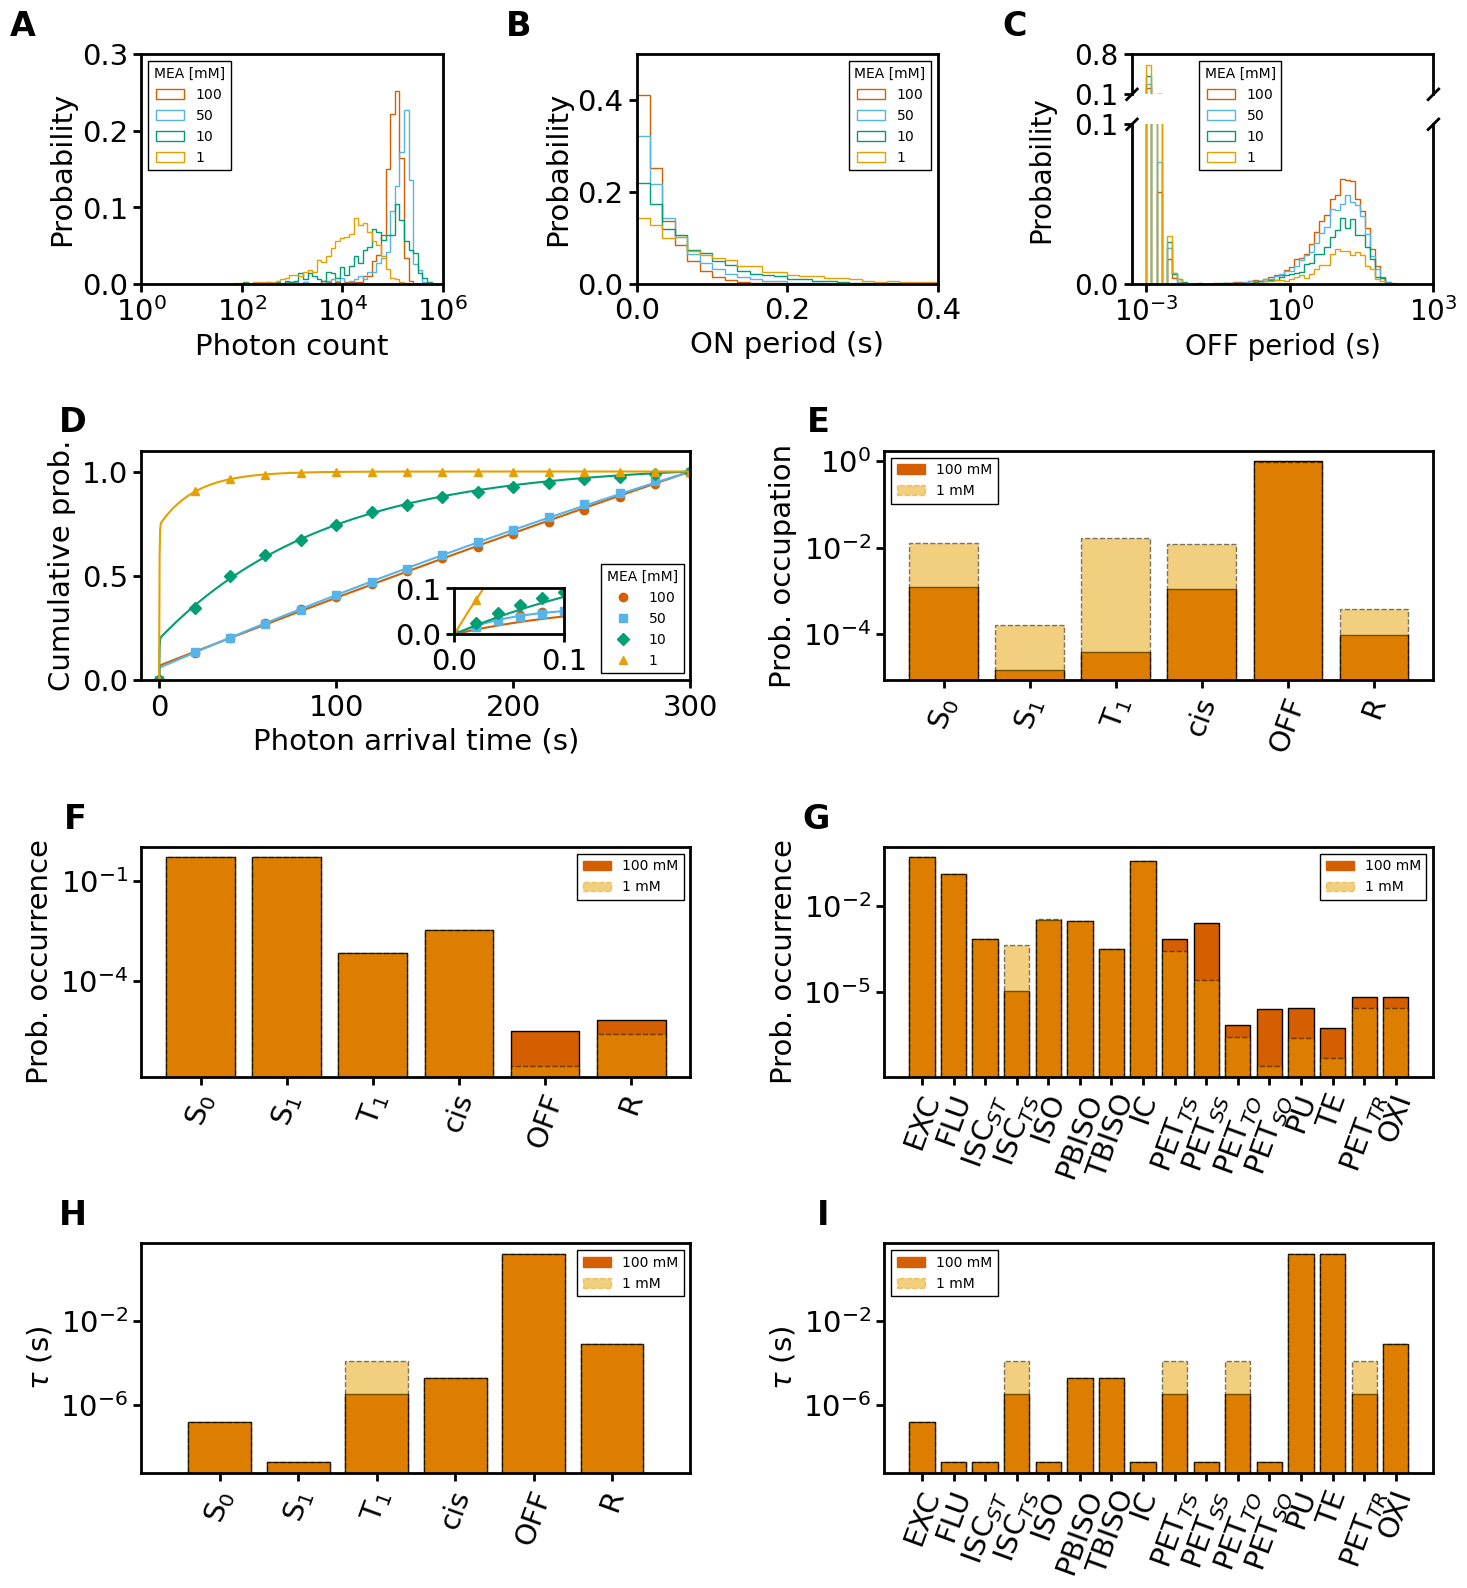

: 

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax, labels, data, fit, legendtitle, xlim2, ylim2, spacing2, colors=colors
):
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        legend=True,
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)],
            color=color,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        legendargs=dict(
            title=legendtitle,
            framealpha=1,
            edgecolor="black",
            fancybox=False,
            title_fontsize=10,
        ),
        **description,
    )

    inset = ax.inset_axes([0.57, 0.2, 0.2, 0.2], xlim=(0, xlim2), ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        pi, lambda1, lambda2 = parameters
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)],
            axes=inset,
            color=color,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 6)
fig = plt.figure(figsize=(15, 16))


ax1 = fig.add_subplot(gs[0, 0:2])
labels1 = [r"$100$", r"$50$", r"$10$", r"$1$"]
legendtitle1 = "MEA [mM]"
fi.universal_figure(
    type_="hist",
    data=list(reversed(total_photons)),
    axes=ax1,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_photons)),
    xscale="log",
    bins=log_bins_photons,
    ylim=[0, 0.3],
    xlim=[1e0, 1e6],
    ylabel="Probability",
    xlabel="Photon count",
    legend=True,
    legendargs=dict(
        title=legendtitle1,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=10,
    ),
)

ax2 = fig.add_subplot(gs[0, 2:4])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods)),
    axes=ax2,
    density=False,
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    weights=list(reversed(weights_ON)),
    ylabel="Probability",
    xlabel="ON period (s)",
    histtype="step",
    bins=60,
    # xticks=[0, 0.3, 0.6],
    legend=True,
    legendargs=dict(
        title=legendtitle1,
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=10,
    ),
    ylim=[0, 0.5],
    xlim=[0, 0.4],
)

bax3 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.8)),
    subplot_spec=gs[0, 4:6],
    despine=False,
    d=0.005,
    height_ratios=(1, 4),
    hspace=0.3,
)
bax3.hist(
    list(reversed(OFF_periods)),
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_OFF,
    weights=list(reversed(weights_OFF)),
)
bax3.set_xscale("log")
bax3.set_ylabel("Probability", fontsize=20, labelpad=55)
bax3.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax3.legend(
    title=legendtitle1,
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(0.2, 0, 1, 1),
)
bax3.tick_params(labelsize=20, width=2, length=6)
bax3.set_xlim([5e-4, 1e3])
bax3.set_xticks([1e-3, 1e0, 1e3])
bax3.axs[0].set_yticks([0.1, 0.8])
bax3.axs[1].set_yticks([0, 0.1])

ax4 = fig.add_subplot(gs[1, 0:3])
plot_figure3(
    ax4,
    labels1,
    fingerprints_all,
    parameters_all_fit_cdf,
    legendtitle1,
    0.1,
    0.1,
    20,
)

legendhandles = [
    mpl.patches.Patch(color=red, label="100 mM"),
    mpl.patches.Patch(color=orange, label="1 mM", alpha=0.5, linestyle="--"),
]


ax5 = fig.add_subplot(gs[1, 3:6])
pred100.plot_state_occupations(axes=ax5, color=red, legend=False)
pred1.plot_state_occupations(
    axes=ax5, alpha=0.5, color=orange, legend=False, linestyle="--"
)
ax5.legend(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    handles=legendhandles,
)
ax6 = fig.add_subplot(gs[2, 0:3])
pred100.plot_frequency_states(axes=ax6, color=red, legend=False)
pred1.plot_frequency_states(
    axes=ax6, alpha=0.5, color=orange, legend=False, linestyle="--"
)
ax6.legend(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    handles=legendhandles,
)
ax7 = fig.add_subplot(gs[2, 3:6])
pred100.plot_frequency_transitions(axes=ax7, color=red, legend=False)
pred1.plot_frequency_transitions(
    axes=ax7, alpha=0.5, color=orange, legend=False, linestyle="--"
)
ax7.legend(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    handles=legendhandles,
)
ax8 = fig.add_subplot(gs[3, 0:3])
pred100.plot_mean_lifetimes(axes=ax8, color=red, legend=False)
pred1.plot_mean_lifetimes(
    axes=ax8, alpha=0.5, color=orange, legend=False, linestyle="--"
)
ax8.legend(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    handles=legendhandles,
)
ax9 = fig.add_subplot(gs[3, 3:6])
pred100.plot_mean_transition_times(axes=ax9, color=red, legend=False)
pred1.plot_mean_transition_times(
    axes=ax9, alpha=0.5, color=orange, legend=False, linestyle="--"
)
ax9.legend(
    framealpha=1,
    edgecolor="black",
    fancybox=False,
    title_fontsize=10,
    handles=legendhandles,
)

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
j = 0
for i, axis in enumerate(axes):
    if i in [2, 3]:
        continue
    offset = -0.35
    if i > 4:
        offset = -0.1
    axis.text(
        offset,
        1.05,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

fig.tight_layout()
for handle3 in bax3.diag_handles:
    handle3.remove()
bax3.draw_diags()

fig.savefig(
    reading_from + r"\single_f_PFA_PET_rate.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)